In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import tensorflow as tf
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split as train_test_split_s
import seaborn as sns

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../..')))
from config import *
from src.models import *
from src.dataset import *
from utils import *

# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"    # ?

set_seed(seed=GLOBAL_SEED)

2025-07-08 14:47:14.707019: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-08 14:47:14.738159: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-08 14:47:15.184988: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
def standardize(X, means, stds):
    return (X - means[None,:,None]) / stds[None,:,None]

In [3]:
def prepare(X, channels=CHANNELS):
    Xt = np.transpose(X, (0, 2, 1))   # [N, window, channels]
    sel = Xt[..., channels]           # отбор каналов
    return sel[..., np.newaxis].astype(np.float32)

In [4]:
def train_model(model, epochs, X_train, y_train, X_valid, y_valid,
                batch_size=BATCH_SIZE, lr=INIT_LR, decay_rate=0.9,
                save_path=None, patience=PATIENCE):
    callbacks = [tf.keras.callbacks.EarlyStopping('val_loss', mode='min', patience=patience)]
    if save_path:
        callbacks.append(
            tf.keras.callbacks.ModelCheckpoint(
                save_path, monitor='val_loss',
                save_best_only=True, save_weights_only=False,    # Сохранять всю архитектуру
                mode='min', verbose=1
            )
        )
    steps = (len(X_train) / batch_size) * 1.5
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        lr, decay_steps=steps, decay_rate=decay_rate
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss='sparse_categorical_crossentropy', metrics=['accuracy']
    )
    return model.fit(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1  # прогресс-бар
    )

## Парсинг данных

In [5]:
WINDOW_SIZE = 56

In [6]:
GESTURE_INDEXES_MAIN

[0, 13, 15, 18, 19, 34, 38, 43, 46]

In [7]:
gestures_dict = {}

for idx in GESTURE_INDEXES_MAIN:
    gestures_dict[f'{idx}'] = np.load(f'../data/discrete/emg_data_{idx}.npy')

In [8]:
emgs, labels = apply_window(gestures_dict, window=WINDOW_SIZE, step=STEP_SIZE)

## Парсинг параметров стандартизации

In [9]:
norm_file = f'../../normalization_values/fold1_win{WINDOW_SIZE}_attention.json'
with open(norm_file, 'r') as f: 
    params = json.load(f)

with open(f'../model_finetuned/fold1_win{WINDOW_SIZE}_attention.json', 'w') as f:
    json.dump(params, f)

X_stand = standardize(emgs, np.array(params['mean']), np.array(params['std']))
X_input = prepare(X_stand)

In [10]:
print(np.mean(X_input, axis=(0, 1, 3)))    # Проверка средних и стандартных отклонений для собранных данных
print(np.std(X_input, axis=(0, 1, 3)))

[0.0112086  0.01252319 0.01074291 0.01410743 0.00893117 0.00536702
 0.00732415 0.0097334 ]
[0.34428537 0.8292893  1.7380323  2.5390356  1.7337164  0.8926842
 1.1857361  0.7459161 ]


## Компиляция модели

In [11]:
input_shape = (WINDOW_SIZE, len(CHANNELS), 1)
model = build_SAM_model(input_shape, FILTERS_BASE, KERNEL_SIZE_BASE, POOL_SIZE_BASE, P_DROPOUT_BASE, NUM_CLASSES)
model.load_weights('../../' + SAVE_PATH + f'_fold1_{WINDOW_SIZE}_attention.h5')

2025-07-08 14:47:16.498234: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-08 14:47:16.545109: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-08 14:47:16.548188: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

### Заморозка слоев

In [12]:
# for layer in model.layers[:6]:
#     layer.trainable = False
model.layers[9].trainable = False    # Заморозка пространственного внимания

### Список активных слоев

In [13]:
for layer in model.layers:
    print(f"{layer.name}: trainable = {layer.trainable}")

input_1: trainable = True
conv2d: trainable = True
batch_normalization: trainable = True
p_re_lu: trainable = True
spatial_dropout2d: trainable = True
max_pooling2d: trainable = True
conv2d_1: trainable = True
batch_normalization_1: trainable = True
p_re_lu_1: trainable = True
spatial_attention: trainable = False
batch_normalization_2: trainable = True
spatial_dropout2d_1: trainable = True
max_pooling2d_1: trainable = True
flatten: trainable = True
dense: trainable = True
softmax: trainable = True


## Оценка претрейна

In [14]:
f1_score_real, report_real, conf_matrix_real = evaluate_metrics(model, X_input, labels)

2025-07-08 14:47:17.293078: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [1555,56,8,1]
	 [[{{node Placeholder/_10}}]]
2025-07-08 14:47:17.293219: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [1555,56,8,1]
	 [[{{node Placeholder/_10}}]]
2025-07-08 14:47:17.397096: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8901


49/49 [==============================] - 1s 929us/step


2025-07-08 14:47:18.081190: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:637] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


In [15]:
print(f'F1 score: {f1_score_real}')

F1 score: 0.2854976510357408


In [16]:
for g in list(report_real.keys())[:-3]:
    print(f'Gesture #{g}')
    print('F1 score: ', report_real[g]['f1-score'])
    print('Precision: ', report_real[g]['precision'])
    print('Recall: ', report_real[g]['recall'])

Gesture #0
F1 score:  0.7226890756302521
Precision:  1.0
Recall:  0.5657894736842105
Gesture #1
F1 score:  0.0
Precision:  0.0
Recall:  0.0
Gesture #2
F1 score:  0.05128205128205128
Precision:  0.05223880597014925
Recall:  0.050359712230215826
Gesture #3
F1 score:  0.5921450151057401
Precision:  0.6490066225165563
Recall:  0.5444444444444444
Gesture #4
F1 score:  0.7511737089201878
Precision:  1.0
Recall:  0.6015037593984962
Gesture #5
F1 score:  0.3215767634854772
Precision:  0.19254658385093168
Recall:  0.9748427672955975
Gesture #6
F1 score:  0.1306122448979592
Precision:  0.26666666666666666
Recall:  0.08648648648648649
Gesture #7
F1 score:  0.0
Precision:  0.0
Recall:  0.0
Gesture #8
F1 score:  0.0
Precision:  0.0
Recall:  0.0


<Axes: >

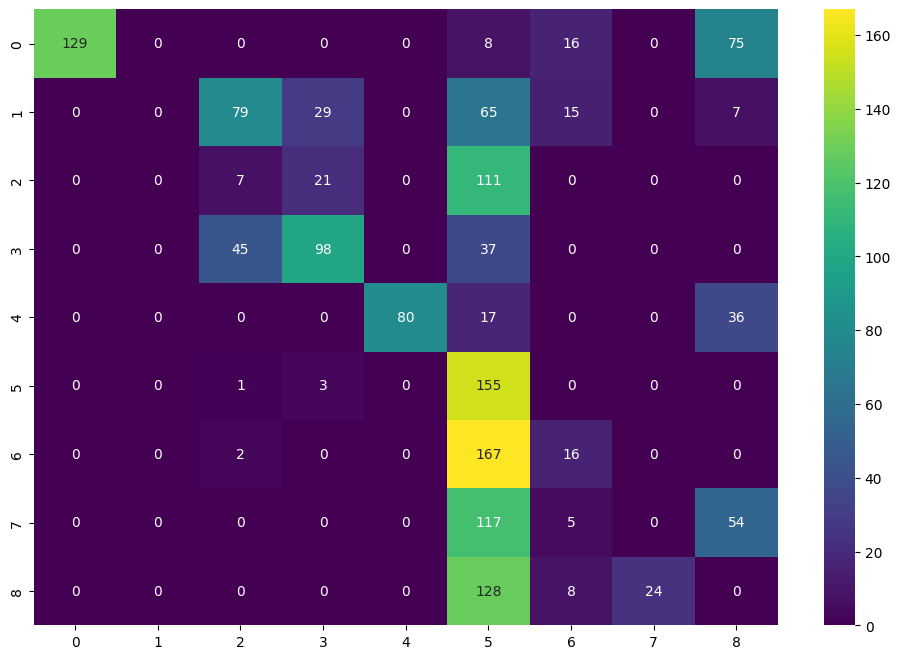

In [17]:
plt.figure(figsize=(12, 8))  # ширина=10, высота=6 дюймов
sns.heatmap(conf_matrix_real, cmap='viridis', annot=True, fmt=".0f")

## Дообучение

In [18]:
X_train, X_test, y_train, y_test = train_test_split_s(X_input, labels.reshape(-1, 1), test_size=0.3, stratify=labels, random_state=42)

In [19]:
os.getcwd()

'/home/etri3060/1_CNN_gestures/LightCBAM_HGR/emg_recorder/notebooks'

Для дообучения надо ставить низкий темп обучения (lr, размер батча), чтобы предотвратить разрушение претрейновых параметров и стабилизировать градиенты.

In [20]:
weights_path = '../model_finetuned/weights.h5'   
train_model(model, 500, X_train=X_train, y_train=y_train, lr=1e-2, X_valid=X_test, y_valid=y_test, 
            batch_size=32, save_path=weights_path) 

Epoch 1/500


2025-07-08 14:47:18.491519: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype int64 and shape [1088,1]
	 [[{{node Placeholder/_11}}]]
2025-07-08 14:47:18.491697: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype int64 and shape [1088,1]
	 [[{{node Placeholder/_11}}]]
2025-07-08 14:47:19.172150: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/spatial_dropout2d/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-07-08 14:47:19.267767: I tenso

32/34 [===========================>..] - ETA: 0s - loss: 3.8159 - accuracy: 0.5596
Epoch 1: val_loss improved from inf to 2.77150, saving model to ../model_finetuned/weights.h5


2025-07-08 14:47:20.445912: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype int64 and shape [467,1]
	 [[{{node Placeholder/_11}}]]
2025-07-08 14:47:20.446087: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype int64 and shape [467,1]
	 [[{{node Placeholder/_11}}]]


34/34 [==============================] - 2s 10ms/step - loss: 3.6693 - accuracy: 0.5625 - val_loss: 2.7715 - val_accuracy: 0.4946
Epoch 2/500
34/34 [==============================] - ETA: 0s - loss: 1.0941 - accuracy: 0.7316
Epoch 2: val_loss improved from 2.77150 to 1.71447, saving model to ../model_finetuned/weights.h5
34/34 [==============================] - 0s 5ms/step - loss: 1.0941 - accuracy: 0.7316 - val_loss: 1.7145 - val_accuracy: 0.6702
Epoch 3/500
19/34 [===============>..............] - ETA: 0s - loss: 0.7949 - accuracy: 0.7829
Epoch 3: val_loss improved from 1.71447 to 1.36644, saving model to ../model_finetuned/weights.h5
34/34 [==============================] - 0s 5ms/step - loss: 0.7170 - accuracy: 0.7941 - val_loss: 1.3664 - val_accuracy: 0.7302
Epoch 4/500
18/34 [==============>...............] - ETA: 0s - loss: 0.5384 - accuracy: 0.8264
Epoch 4: val_loss improved from 1.36644 to 1.00954, saving model to ../model_finetuned/weights.h5
34/34 [==========================

## Оценка дообученной модели

In [21]:
f1_score_real, report_real, conf_matrix_real = evaluate_metrics(model, X_test, y_test)

15/15 [==============================] - 0s 932us/step


2025-07-08 14:47:28.209272: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [467,56,8,1]
	 [[{{node Placeholder/_10}}]]
2025-07-08 14:47:28.209432: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [467,56,8,1]
	 [[{{node Placeholder/_10}}]]


In [22]:
print(f'F1 score: {f1_score_real}')

F1 score: 0.817692411185654


In [23]:
for g in list(report_real.keys())[:-3]:
    print(f'Gesture #{g}')
    print('F1 score: ', report_real[g]['f1-score'])
    print('Precision: ', report_real[g]['precision'])
    print('Recall: ', report_real[g]['recall'])

Gesture #0
F1 score:  0.9696969696969697
Precision:  1.0
Recall:  0.9411764705882353
Gesture #1
F1 score:  0.5904761904761905
Precision:  0.6739130434782609
Recall:  0.5254237288135594
Gesture #2
F1 score:  0.6933333333333334
Precision:  0.7878787878787878
Recall:  0.6190476190476191
Gesture #3
F1 score:  0.8064516129032258
Precision:  0.7142857142857143
Recall:  0.9259259259259259
Gesture #4
F1 score:  0.9743589743589743
Precision:  1.0
Recall:  0.95
Gesture #5
F1 score:  0.8351648351648352
Precision:  0.8837209302325582
Recall:  0.7916666666666666
Gesture #6
F1 score:  0.7787610619469026
Precision:  0.7586206896551724
Recall:  0.8
Gesture #7
F1 score:  0.8292682926829268
Precision:  0.7285714285714285
Recall:  0.9622641509433962
Gesture #8
F1 score:  0.8817204301075269
Precision:  0.9111111111111111
Recall:  0.8541666666666666


<Axes: >

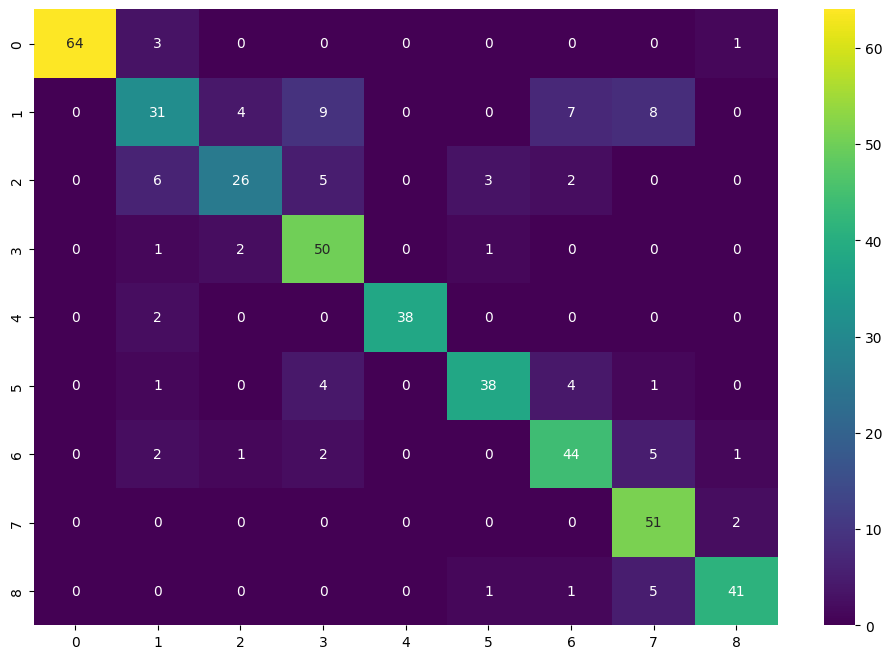

In [24]:
plt.figure(figsize=(12, 8))  # ширина=10, высота=6 дюймов
sns.heatmap(conf_matrix_real, cmap='viridis', annot=True, fmt=".0f")